In [1]:
import s3fs
import polars as pl

fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

synth_path = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/retext-2026-05-29_gemma4-26b-moe_temp10_fewshot6_exhaustive.parquet"
original_train_path = "s3://projet-ape/data/08112022_27102024/naf2025/split/df_train.parquet"

with fs.open(synth_path) as f:
    df_synth = pl.read_parquet(f)

with fs.open(original_train_path) as f:
    df_real = pl.read_parquet(f)

In [2]:
df_real = df_real.rename(mapping={"nace2025": "code", "libelle": "label"})[["code", "label"]]
df_real = df_real.with_columns(
    (pl.col("code").str.slice(0, 2) + "." + pl.col("code").str.slice(2)).alias("code")
)

df_synth = df_synth[["code", "label"]]

## Tokenizer choice

### Output dimension

In [3]:
df_synth_word = df_synth.with_columns(
    pl.col("label")
    .str.split(by=" ")
    .list.len()
    .alias("nombre_de_mots")
)

df_real_word = df_real.with_columns(
    pl.col("label")
    .str.split(by=" ")
    .list.len()
    .alias("nombre_de_mots")
)

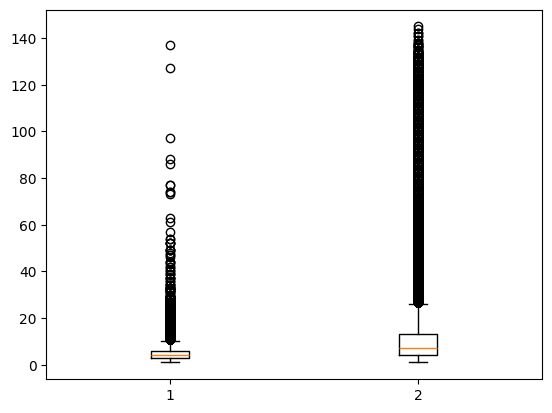

In [4]:
import matplotlib.pyplot as plt

plt.boxplot([df_synth_word["nombre_de_mots"], df_real_word["nombre_de_mots"]])
plt.show()

In [5]:
stats_synth = df_synth_word.select(
    [pl.col("nombre_de_mots").quantile(0.90).alias("p90"),
    pl.col("nombre_de_mots").quantile(0.95).alias("p95"),
    pl.col("nombre_de_mots").quantile(0.99).alias("p99"),
    pl.col("nombre_de_mots").quantile(0.995).alias("p995"),
    pl.col("nombre_de_mots").quantile(0.999).alias("p999"),]
)

print(stats_synth)

stats_real = df_real_word.select(
    [pl.col("nombre_de_mots").quantile(0.90).alias("p90"),
    pl.col("nombre_de_mots").quantile(0.95).alias("p95"),
    pl.col("nombre_de_mots").quantile(0.99).alias("p99"),
    pl.col("nombre_de_mots").quantile(0.995).alias("p995"),
    pl.col("nombre_de_mots").quantile(0.999).alias("p999"),]
)

print(stats_real)

shape: (1, 5)
┌──────┬──────┬──────┬──────┬──────┐
│ p90  ┆ p95  ┆ p99  ┆ p995 ┆ p999 │
│ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  │
╞══════╪══════╪══════╪══════╪══════╡
│ 11.0 ┆ 16.0 ┆ 23.0 ┆ 25.0 ┆ 33.0 │
└──────┴──────┴──────┴──────┴──────┘
shape: (1, 5)
┌──────┬──────┬──────┬──────┬──────┐
│ p90  ┆ p95  ┆ p99  ┆ p995 ┆ p999 │
│ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  │
╞══════╪══════╪══════╪══════╪══════╡
│ 21.0 ┆ 23.0 ┆ 26.0 ┆ 29.0 ┆ 84.0 │
└──────┴──────┴──────┴──────┴──────┘


In [6]:
print(len(df_real_word.filter(pl.col("nombre_de_mots") > 32)))
print(len(df_synth_word.filter(pl.col("nombre_de_mots") > 32)))
print(len(df_real) + len(df_synth))

5869
56
1577103


Let's choose 32 (we truncate a really small proportion of samples)

### Vocab size

In [54]:
import numpy as np
from torchTextClassifiers.tokenizers import WordPieceTokenizer

OUTPUT_DIM = 32

def test_vocab_size(X_train, X_val, vocab_size):
    tokenizer = WordPieceTokenizer(vocab_size=vocab_size, output_dim=OUTPUT_DIM)
    tokenizer.train(X_train)
    output = tokenizer.tokenize(list(X_val))
    token_list = output.input_ids.numpy().flatten()
    sum_tokens = sum(token_list > 1)
    unk_tokens = sum(token_list == 0)
    word_list = np.char.split(list(X_val))
    word_list= np.concatenate(word_list).ravel()

    return sum_tokens/len(word_list), unk_tokens/len(word_list)

In [55]:
vocab_sizes = [1000, 2000, 3000, 4000, 5000, 7500, 10000, 12500, 15000, 17500, 20000]

#### No preprocessing

In [56]:
df_train = pl.concat([df_synth, df_real.sample(n=50000)])
X_train = df_train["label"].to_numpy()
X_val = df_real.sample(50000)["label"].to_numpy()

In [57]:
ratios = []
unknowns = []

for vs in vocab_sizes:
    ratio_tokens, ratio_unk = test_vocab_size(X_train, X_val, vs) 
    ratios.append(ratio_tokens)
    unknowns.append(ratio_unk)

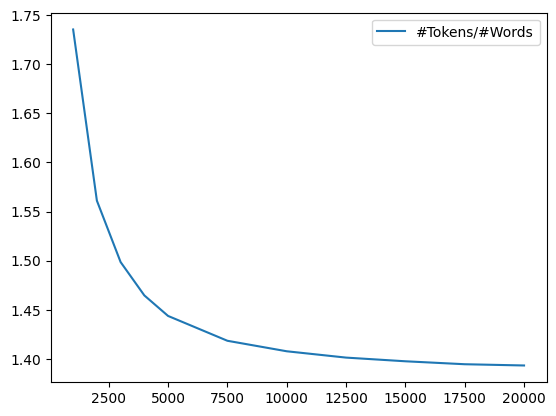

In [58]:
plt.plot(vocab_sizes, ratios, label="#Tokens/#Words")
plt.legend()
plt.show()

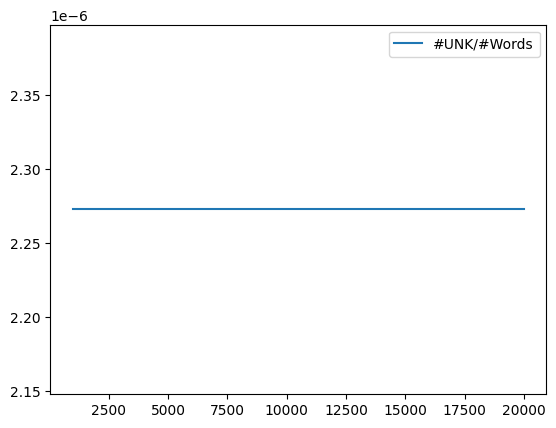

In [59]:
plt.plot(vocab_sizes, unknowns, label="#UNK/#Words")
plt.legend()
plt.show()

Le ratio #Tokens/#Words est élevé dans tous les cas, probablement car on a gardé la ponctuation (et donc des "d'après" sont en 1 mots mais 3 tokens, des "service." sont en 1 mot mais 2 tokens, ...). Bonne nouvelle : on arrive à attraper presque l'intégralité du vocabulaire.

#### Preprocessing

In [46]:
import sys
sys.path.append("../")

import nltk
import data as data
nltk.download('stopwords')
from nltk.corpus import stopwords

french_stopwords = stopwords.words('french')

df_preprocessed = data.preprocess(df_train, text_column="label", stopwords=french_stopwords)
X_preprocessed, y_preprocessed = df_preprocessed["label"].to_numpy(), df_preprocessed["code"].to_numpy()

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [64]:
df_val = pl.DataFrame(X_val, schema=["label"])
df_val_preprocessed = data.preprocess(df_val, text_column="label", stopwords=french_stopwords)

In [66]:
X_val_preprocessed = df_val_preprocessed["label"].to_numpy()

In [67]:
ratios_preprocessed = []
unknowns_preprocessed = []

for vs in vocab_sizes:
    ratio_tokens, ratio_unk = test_vocab_size(X_preprocessed, X_val_preprocessed, vs) 
    ratios_preprocessed.append(ratio_tokens)
    unknowns_preprocessed.append(ratio_unk)

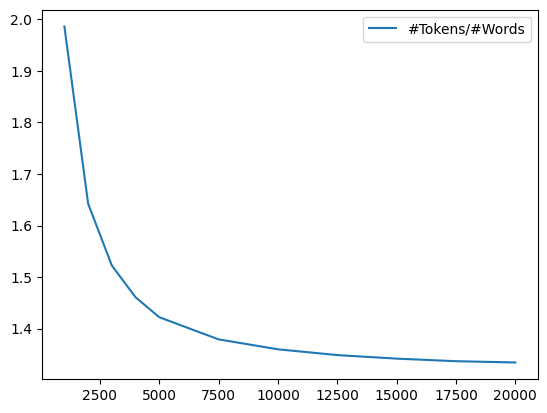

In [68]:
plt.plot(vocab_sizes, ratios_preprocessed, label="#Tokens/#Words")
plt.legend()
plt.show()

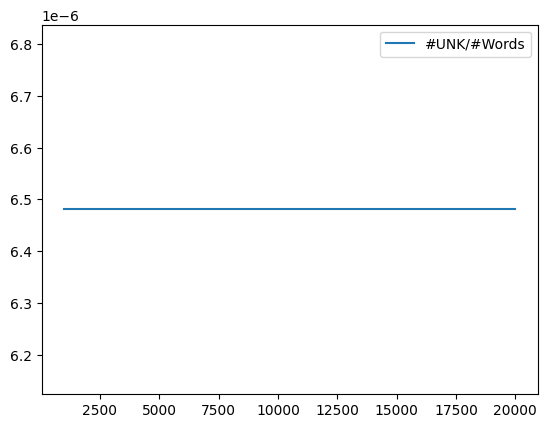

In [69]:
plt.plot(vocab_sizes, unknowns_preprocessed, label="#UNK/#Words")
plt.legend()
plt.show()

On arrive à descendre plus bas dans le ratio, mais pas de tellement. Dans tous les cas, le nombre d'unkown tokens reste très bas.

On gagne plus tant de perofrmances après 10000 de vocab_size : on garde cette valeur.